# Data preparation

In [4]:
!pip install pydicom
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage

# Authenticate and set up environment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'final_combined_data.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/final_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)

# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 8.9 MB/s eta 0:00:00
Updated property [core/project].


In [5]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage

# Check for NaN values in the dataset and drop rows with NaN values
df_clean = df.dropna()

# Save the cleaned data back to the same CSV file
df_clean.to_csv(local_filtered_data_path, index=False)
filtered_blob.upload_from_filename(local_filtered_data_path)

print("Cleaned data saved to GCP bucket at: gs://{bucket_name}/final_combined_data.csv")

# Load the cleaned data for further processing
df = pd.read_csv(local_filtered_data_path)

# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

Updated property [core/project].
Cleaned data saved to GCP bucket at: gs://{bucket_name}/final_combined_data.csv


# PCA from embeddings


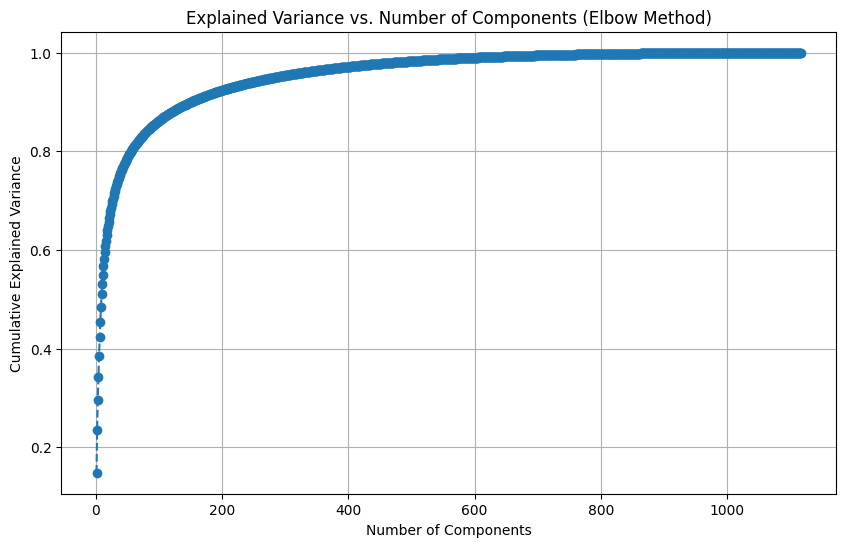

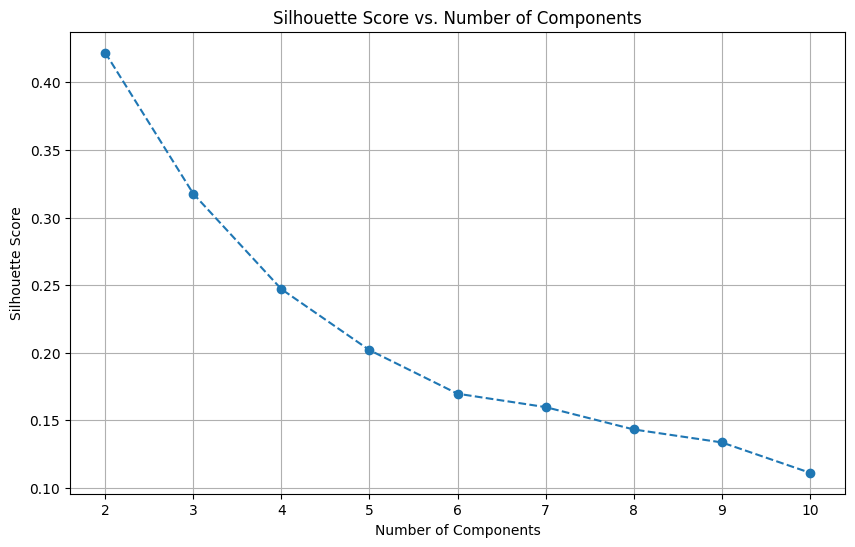

The optimal number of components based on silhouette score is: 2


In [6]:
# Determine the optimal number of PCA components using the elbow method
pca = PCA()
embeddings_pca = pca.fit_transform(embeddings)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance to use the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components (Elbow Method)')
plt.grid()
plt.show()

# Using the Silhouette method to determine the optimal number of components
def optimal_number_of_components(data, max_components=10):
    silhouette_scores = []
    for n_components in range(2, max_components + 1):
        pca = PCA(n_components=n_components)
        transformed_data = pca.fit_transform(data)
        kmeans = KMeans(n_clusters=n_components, n_init=10)  # Explicitly set n_init
        kmeans.fit(transformed_data)
        score = silhouette_score(transformed_data, kmeans.labels_)
        silhouette_scores.append(score)

    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_components + 1), silhouette_scores, marker='o', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs. Number of Components')
    plt.grid()
    plt.show()

    optimal_components = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
    return optimal_components

# Display optimal number of features using silhouette score
optimal_components = optimal_number_of_components(embeddings)
print(f'The optimal number of components based on silhouette score is: {optimal_components}')

# Apply PCA with optimal number of components
pca = PCA(n_components=optimal_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

In [4]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import statsmodels.api as sm

# Assuming embeddings is a numpy array with your embedding data
# and df is your original DataFrame

# Choose the number of components based on the elbow method graph
chosen_components = 100

# Apply PCA with chosen number of components
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe using pd.concat to avoid fragmentation
pca_columns = pd.DataFrame(embeddings_pca, columns=[f'pca_{i+1}' for i in range(chosen_components)])
df = pd.concat([df.reset_index(drop=True), pca_columns.reset_index(drop=True)], axis=1)

# Check for NaN values in the dataset
if df.isnull().values.any():
    print("Data contains NaN values. Please handle missing data before running regression.")
    print(df.isnull().sum())
else:
    # Prepare the data for regression analysis
    X = df[[f'pca_{i+1}' for i in range(chosen_components)]]
    y = df['avg_peep']

    # Ensure data types are correct
    if not np.issubdtype(y.dtype, np.number):
        print("The target variable 'avg_peep' must be numeric.")
    else:
        # Univariate PCA logistic regression (changing from multivariate to univariate)
        # Here we use each PCA component individually to fit the regression model
        significant_components = []
        for i in range(chosen_components):
            Xi = sm.add_constant(X[[f'pca_{i+1}']])
            model = sm.OLS(y, Xi)
            result = model.fit()
            p_value = result.pvalues.iloc[1]  # Access the p-value of the PCA component coefficient by position using iloc
            if p_value < 0.1:
                significant_components.append(i+1)
                print(f'Regression summary for PCA component {i+1}')
                print(result.summary())

# Save the significant components as a list
print("Significant PCA components:", significant_components)


Regression summary for PCA component 1
                            OLS Regression Results                            
Dep. Variable:               avg_peep   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     7.802
Date:                Mon, 05 Aug 2024   Prob (F-statistic):           0.000432
Time:                        10:56:04   Log-Likelihood:                -3149.0
No. Observations:                1117   AIC:                             6304.
Df Residuals:                    1114   BIC:                             6319.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

# PCA heat intensity mapping


In [ ]:
import tensorflow as tf

# Function to inspect a TFRecord file
def inspect_tfrecord(tfrecord_path):
    raw_dataset = tf.data.TFRecordDataset(tfrecord_path)
    for raw_record in raw_dataset.take(1):
        example = tf.train.Example()
        example.ParseFromString(raw_record.numpy())
        print(example)

# Path to one of your TFRecord files
tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Inspect the contents of the TFRecord file
inspect_tfrecord(tfrecord_path)

features {
  feature {
    key: "embedding"
    value {
      float_list {
        value: 0.12571078538894653
        value: -1.8030073642730713
        value: 1.284251093864441
        value: -1.8088324069976807
        value: 0.12782026827335358
        value: -0.1911957710981369
        value: 0.609272301197052
        value: 0.8305790424346924
        value: -0.4437893033027649
        value: 1.2388948202133179
        value: -0.731681227684021
        value: -0.046644363552331924
        value: -0.0726856216788292
        value: -0.09150750190019608
        value: 1.9036893844604492
        value: 1.2494566440582275
        value: -0.9712356328964233
        value: 1.454064130783081
        value: 0.3265739381313324
        value: 0.30579227209091187
        value: 2.5591158866882324
        value: 2.239715337753296
        value: -2.6466915607452393
        value: 0.5688884258270264
        value: 0.7315727472305298
        value: 0.684329628944397
        value: -1.8385820388793

In [ ]:
import tensorflow as tf

def parse_tfrecord_fn(example):
    feature_description = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(example, feature_description)
    embedding = example['embedding']
    image_format = example['image/format']
    image_id = example['image/id']
    return embedding, image_format, image_id

def load_embeddings_and_image_ids(tfrecord_path):
    raw_dataset = tf.data.TFRecordDataset(tfrecord_path)
    parsed_dataset = raw_dataset.map(parse_tfrecord_fn)
    embeddings = []
    image_ids = []
    for embedding, image_format, image_id in parsed_dataset:
        embeddings.append(embedding.numpy())
        image_ids.append(image_id.numpy().decode('utf-8'))
    return embeddings, image_ids

tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Load embeddings and image IDs from the TFRecord
embeddings, image_ids = load_embeddings_and_image_ids(tfrecord_path)


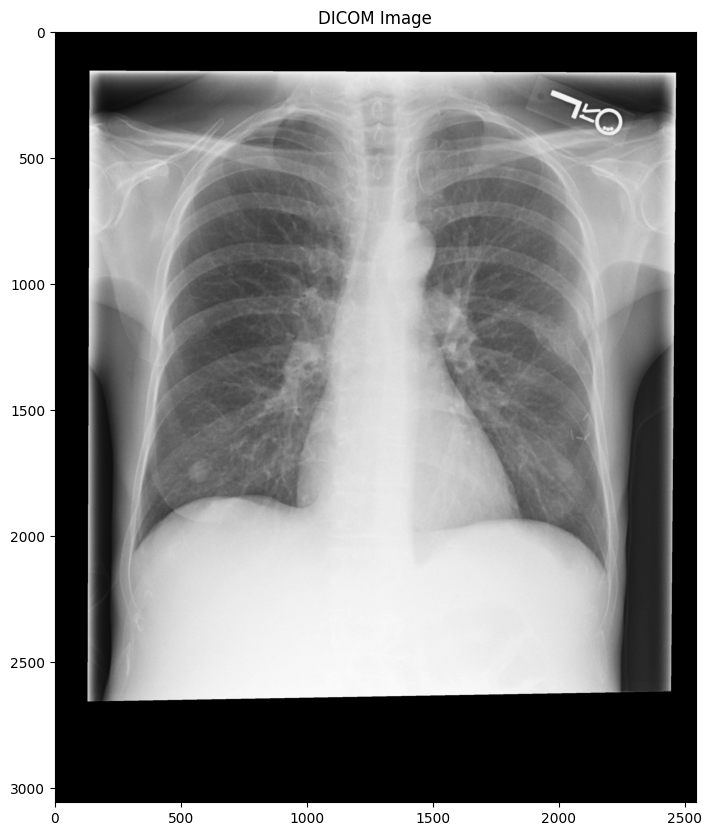

In [ ]:
!pip install pydicom
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

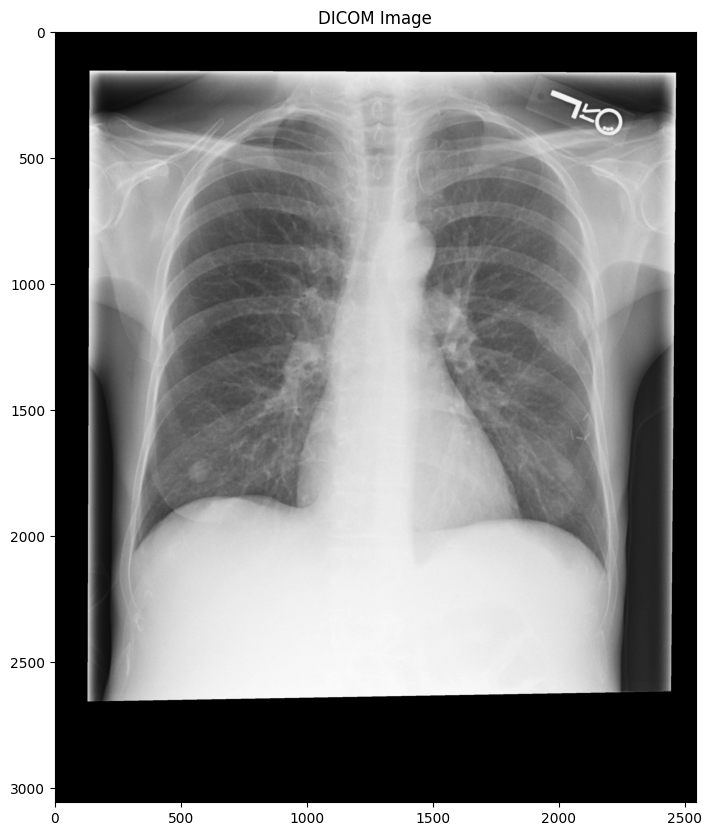

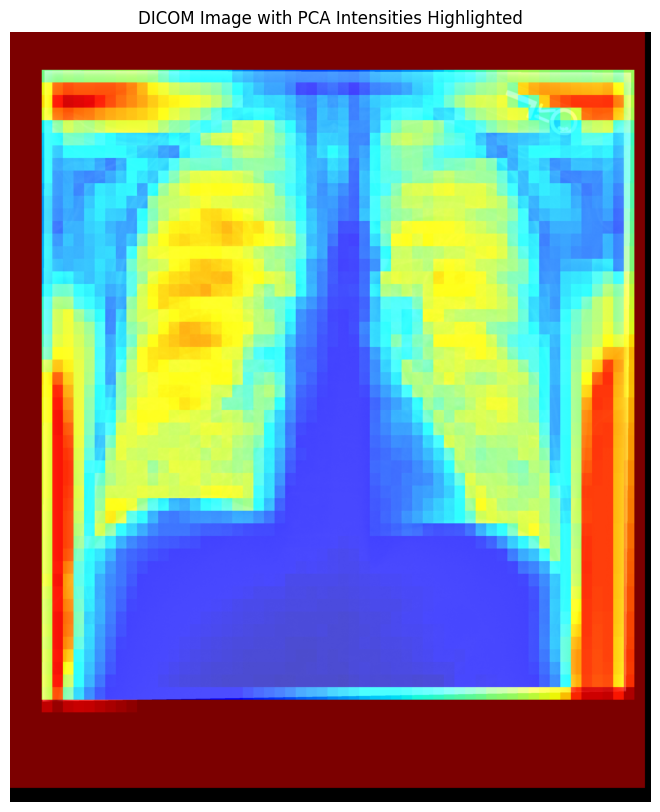

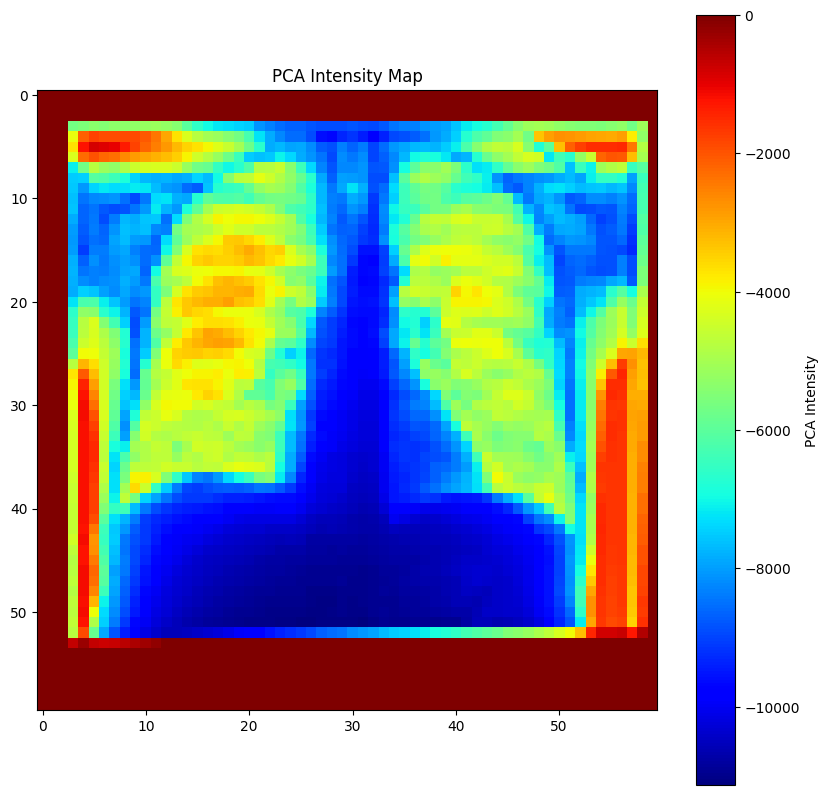

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
# Replace the hardcoded list with the output from the previous script
significant_components = [4, 5, 7, 9, 10, 12, 15, 19, 20, 23, 24, 30, 32, 37, 42, 48, 49, 55, 70, 84, 86, 88, 91]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 60
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

# Create an empty mask for the full image
intensity_map = np.zeros((num_rois, num_rois))

# Calculate PCA intensities for each ROI and store them in the intensity map
for i, roi in enumerate(rois):
    roi_intensity = 0
    for component in significant_components:
        if component - 1 >= len(pca_features):
            print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
            continue

        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature
        roi_intensity += pca_intensity

    intensity_map[i // num_rois, i % num_rois] = roi_intensity

# Normalize the intensity map for color mapping
intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

# Create the overlay image with a color map and transparency
overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
alpha = 0.98  # Transparency level

for i, roi in enumerate(rois):
    intensity = intensity_map_normalized[i // num_rois, i % num_rois]
    color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
    for j in range(3):  # Apply color to the RGB channels
        overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

# Display the overlay image
plt.figure(figsize=(10, 10))
plt.imshow(overlay_image)
plt.title('DICOM Image with PCA Intensities Highlighted')
plt.axis('off')
plt.show()

# Display the intensity map for reference
plt.figure(figsize=(10, 10))
plt.imshow(intensity_map, cmap='jet')
plt.colorbar(label='PCA Intensity')
plt.title('PCA Intensity Map')
plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example1.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example1.tfrecord')
blob.download_to_filename(tfrecord_path)

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [4, 5, 7, 9, 10, 12, 15, 19, 20, 23, 24, 30, 32, 37, 42, 48, 49, 55, 70, 84, 86, 88, 91]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a grid)
height, width = image_array.shape
num_rois = 60  # Adjust the grid size as needed
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

# Threshold for visualization
threshold = 1e4  # Example threshold value, adjust based on your data

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map for color mapping
    intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.99  # Transparency level

    for i, roi in enumerate(rois):
        intensity = intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity')
    plt.title(f'PCA Component {component} Intensity Map')
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

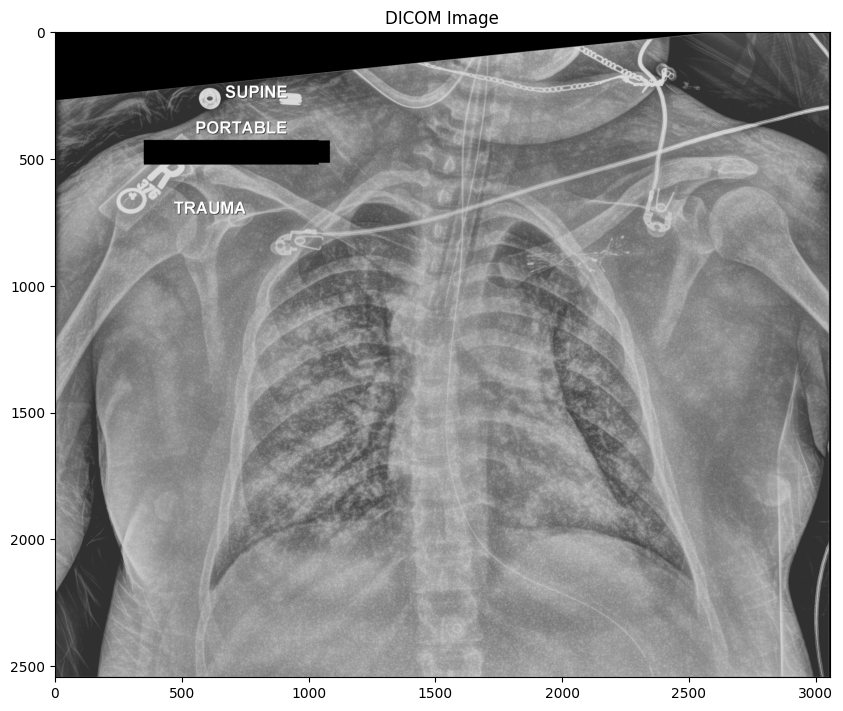

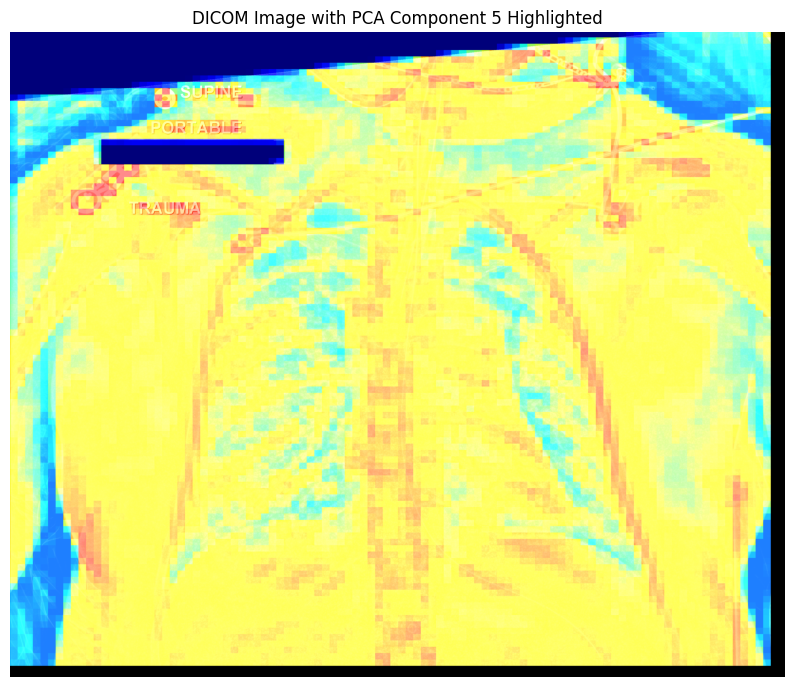

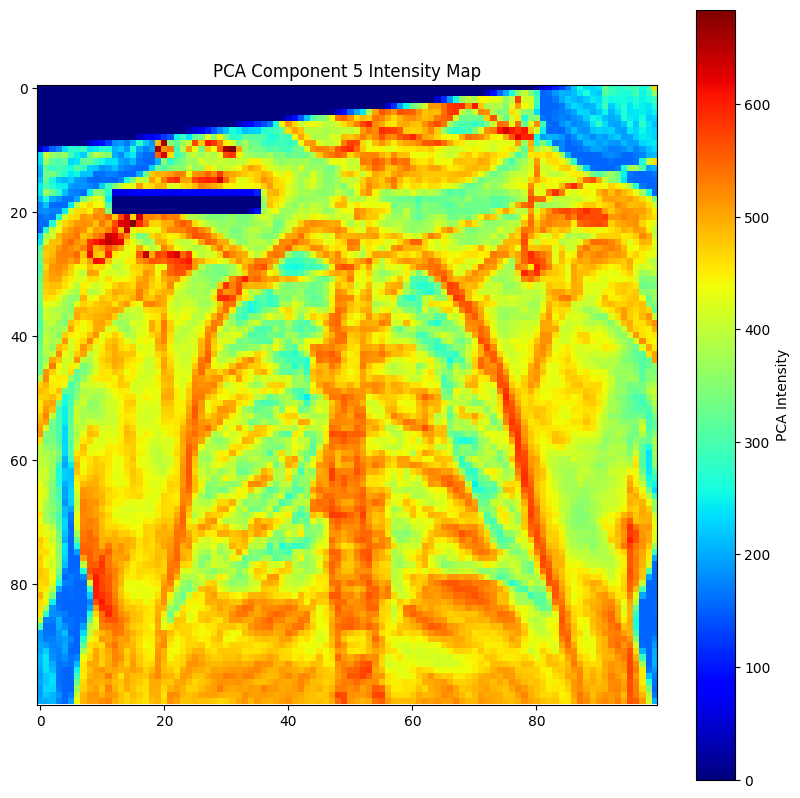

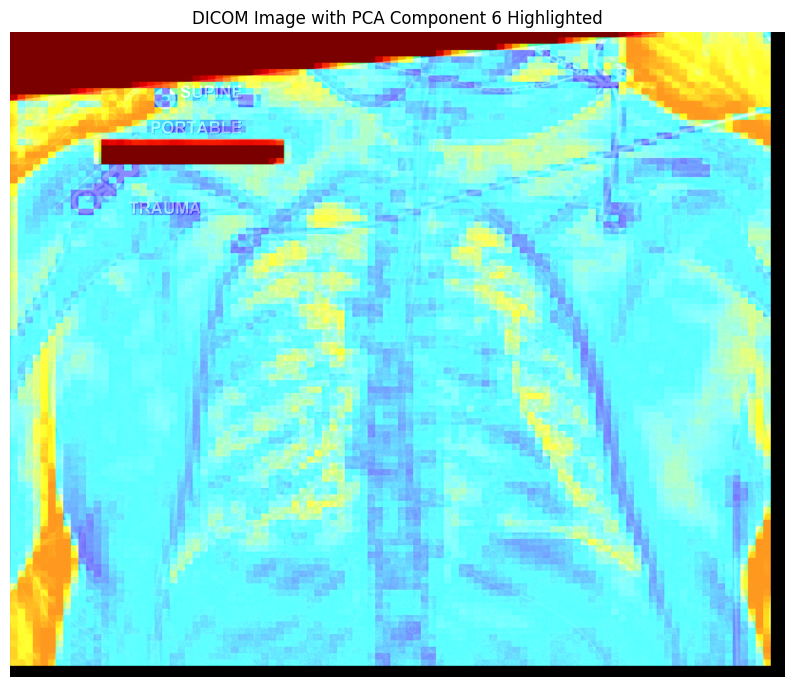

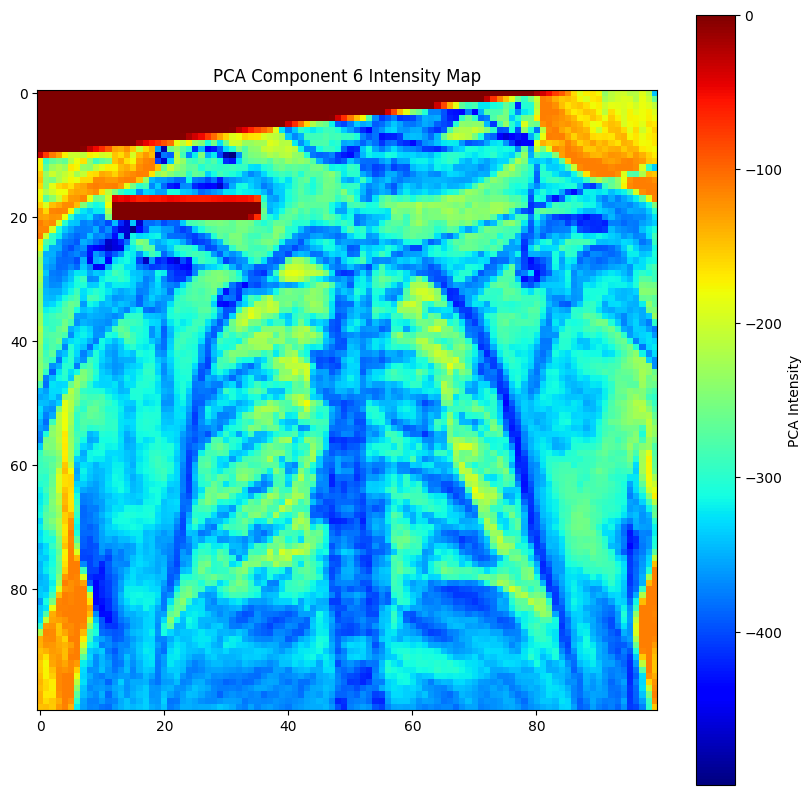

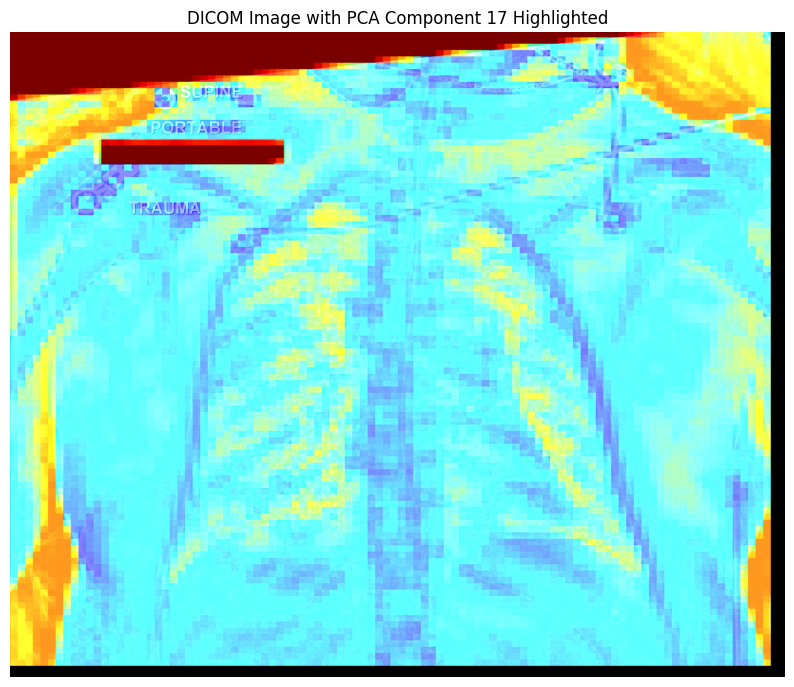

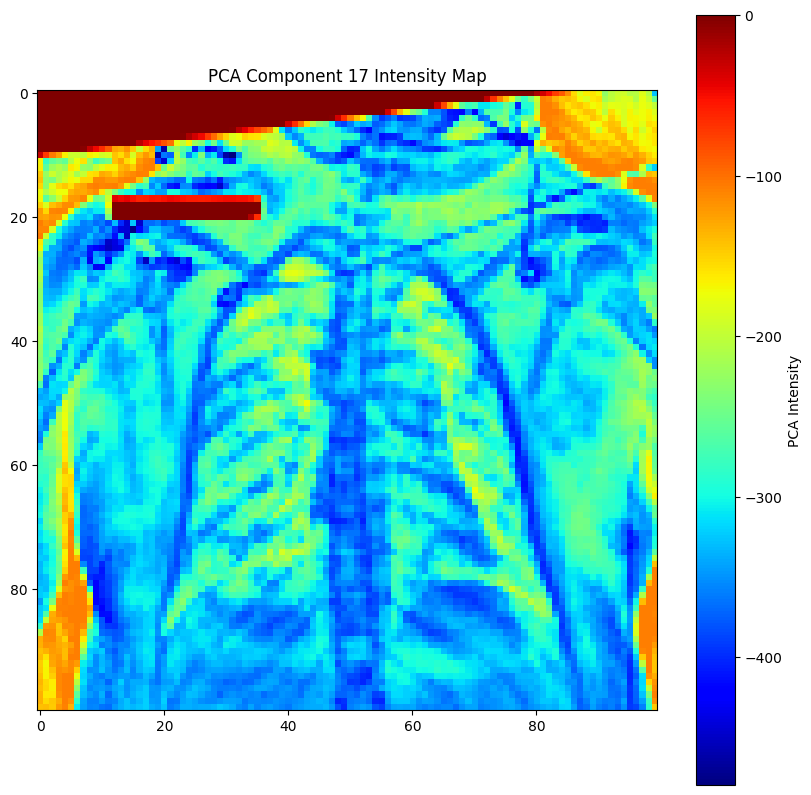

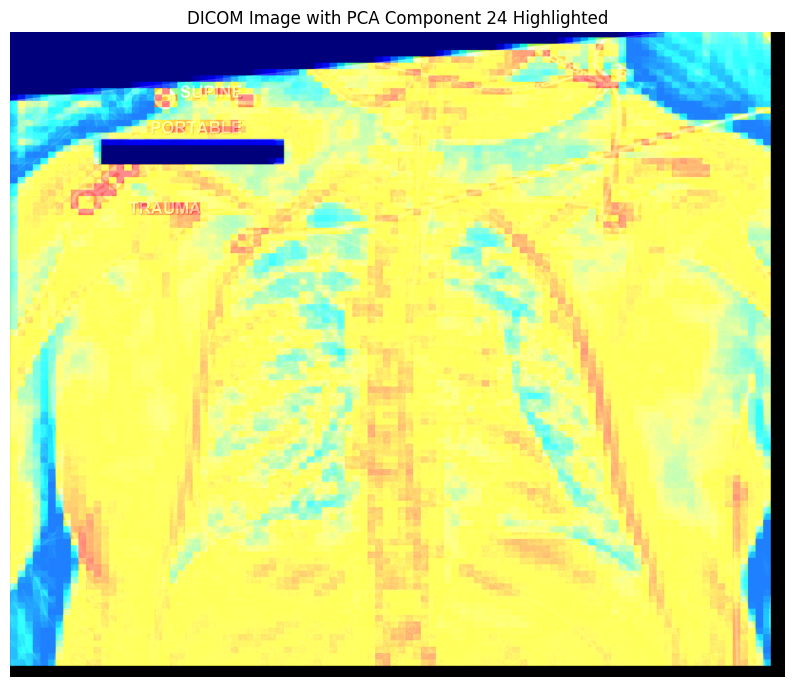

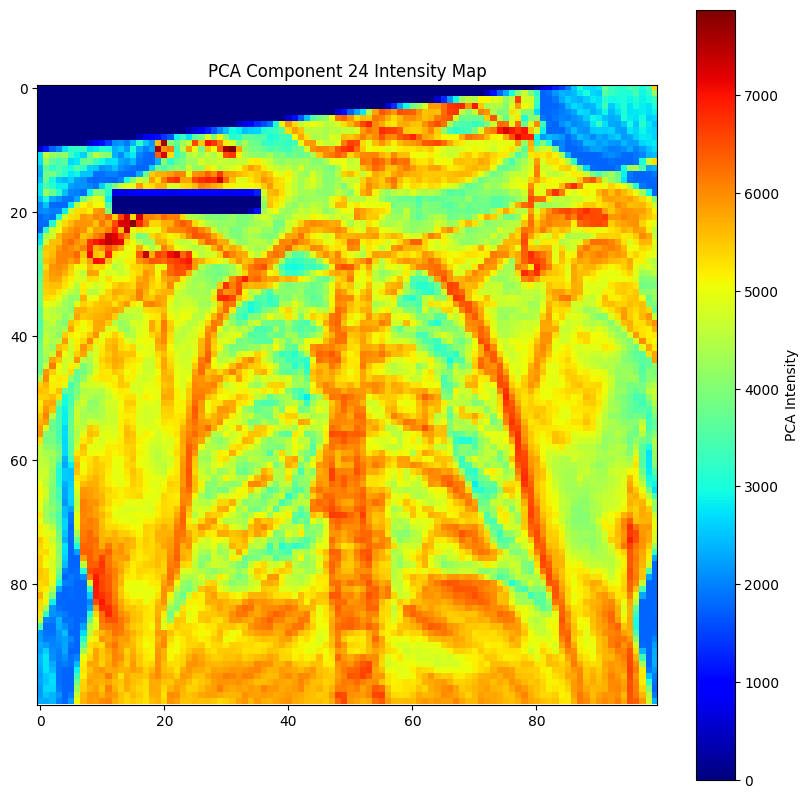

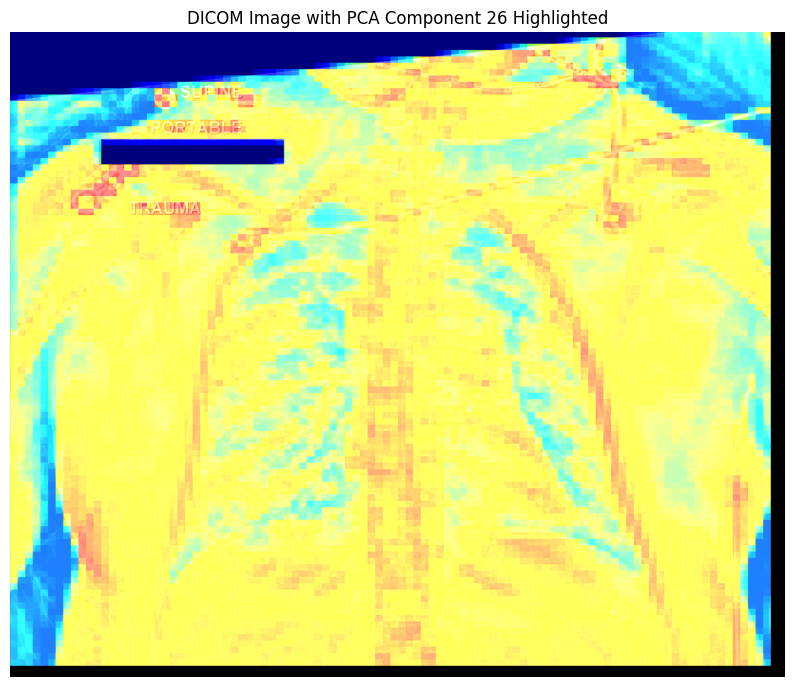

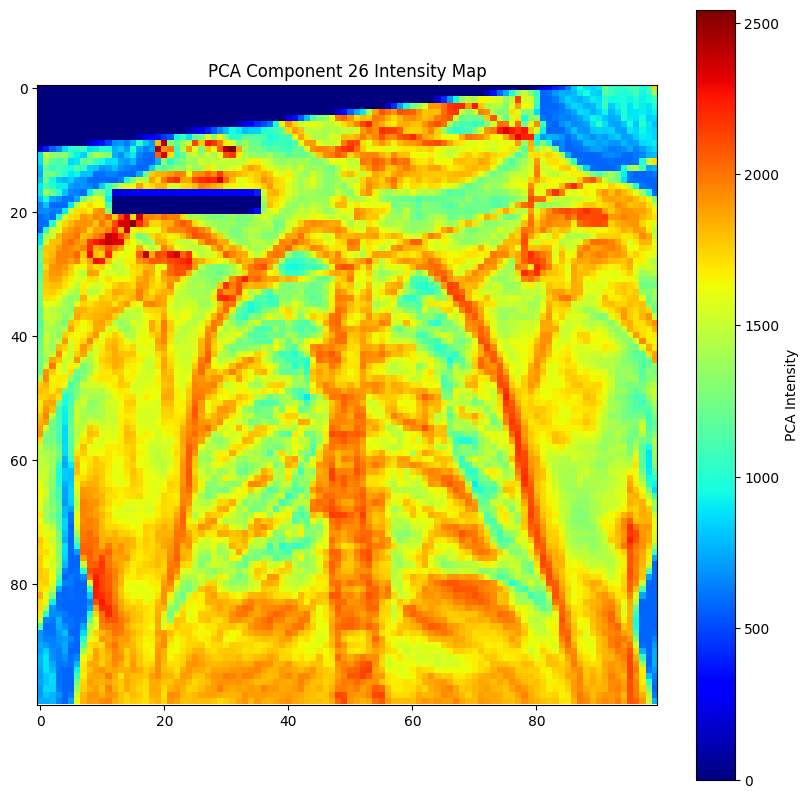

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example2.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example2.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example2.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example2.tfrecord')
blob.download_to_filename(tfrecord_path)
# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example2.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

# Threshold for visualization
threshold = 1e4  # Example threshold value, adjust based on your data

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map for color mapping
    intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.96  # Transparency level

    for i, roi in enumerate(rois):
        intensity = intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity')
    plt.title(f'PCA Component {component} Intensity Map')
    plt.show()

    # Print the intensity values for each ROI
    #for i, roi in enumerate(rois):
    #    print(f"ROI {roi}: Intensity: {intensity_map[i // num_rois, i % num_rois]}")


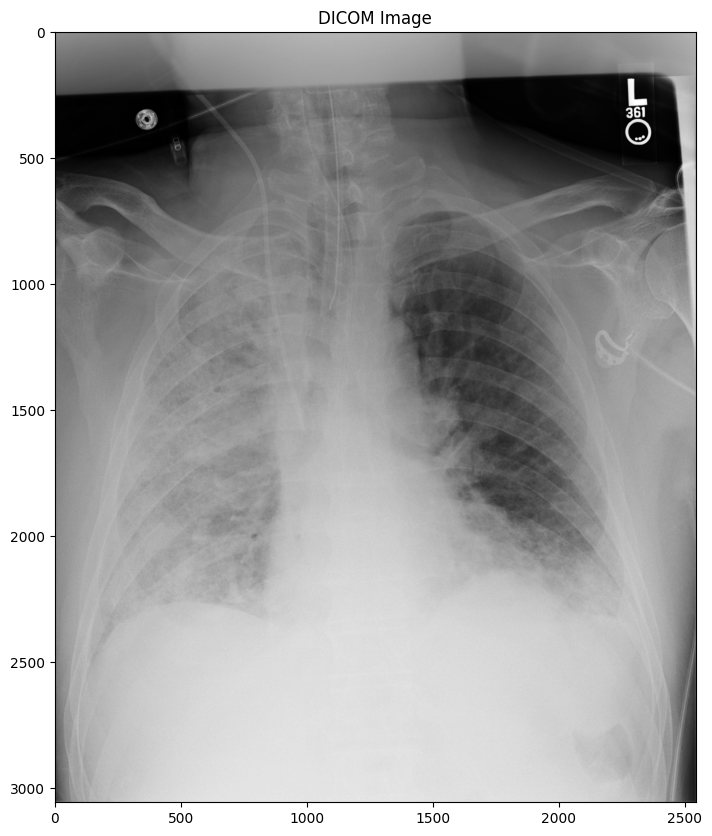

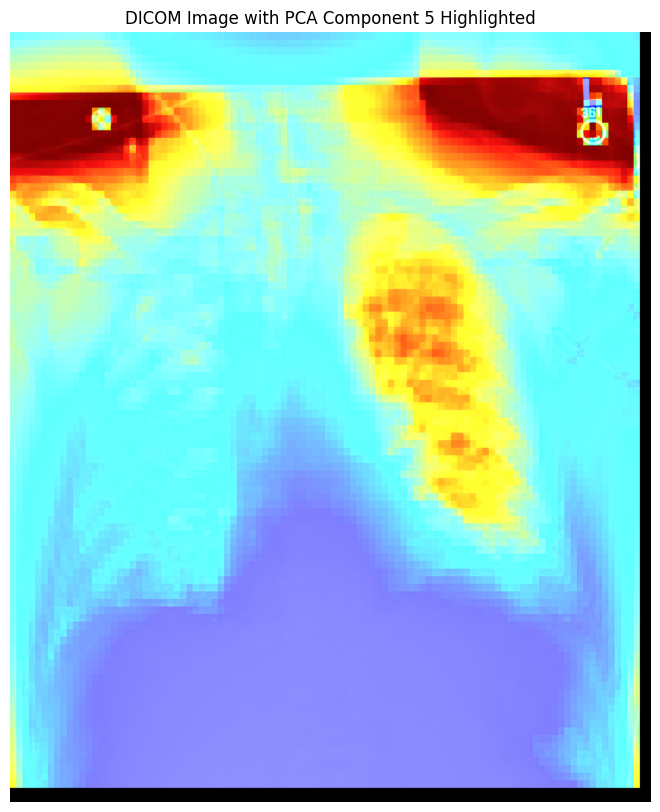

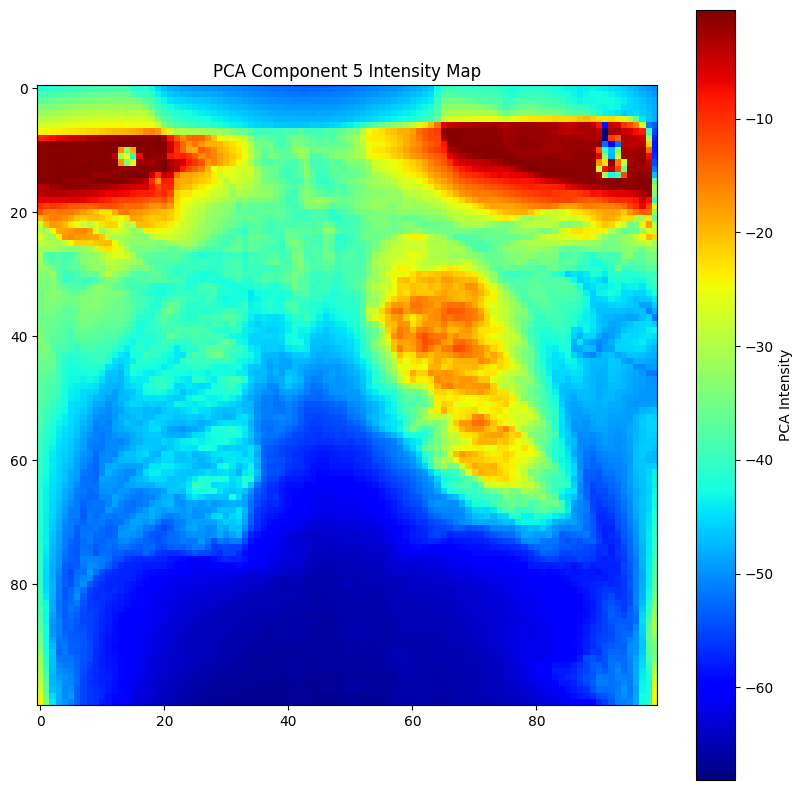

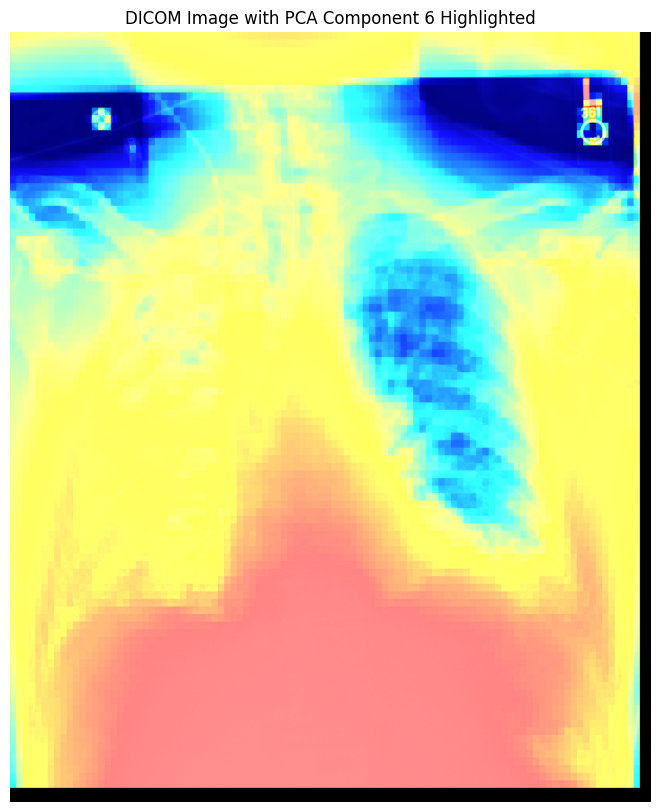

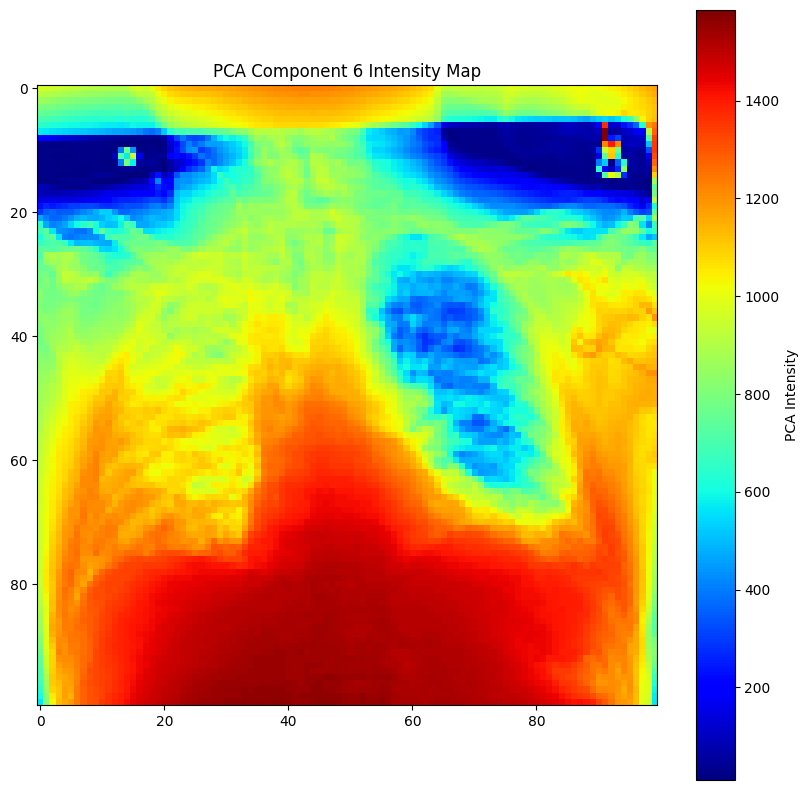

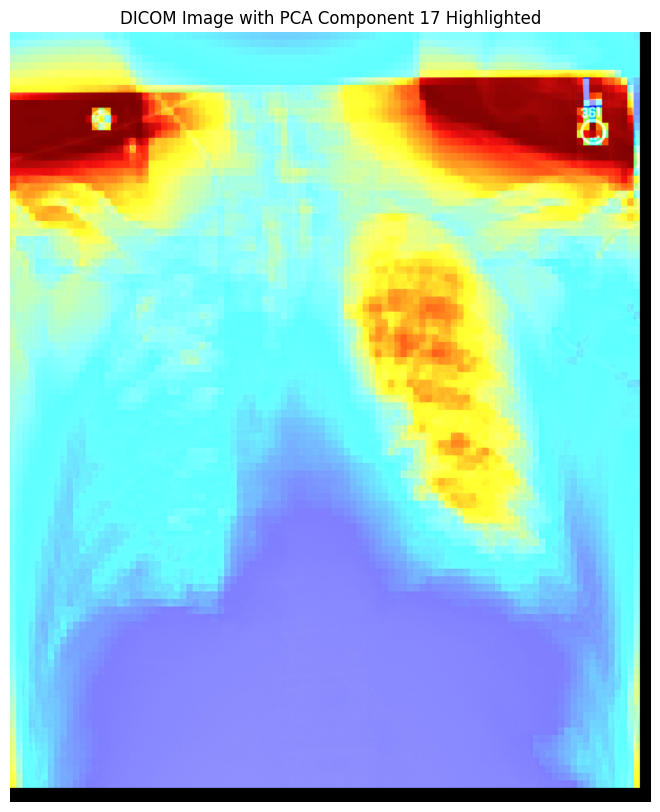

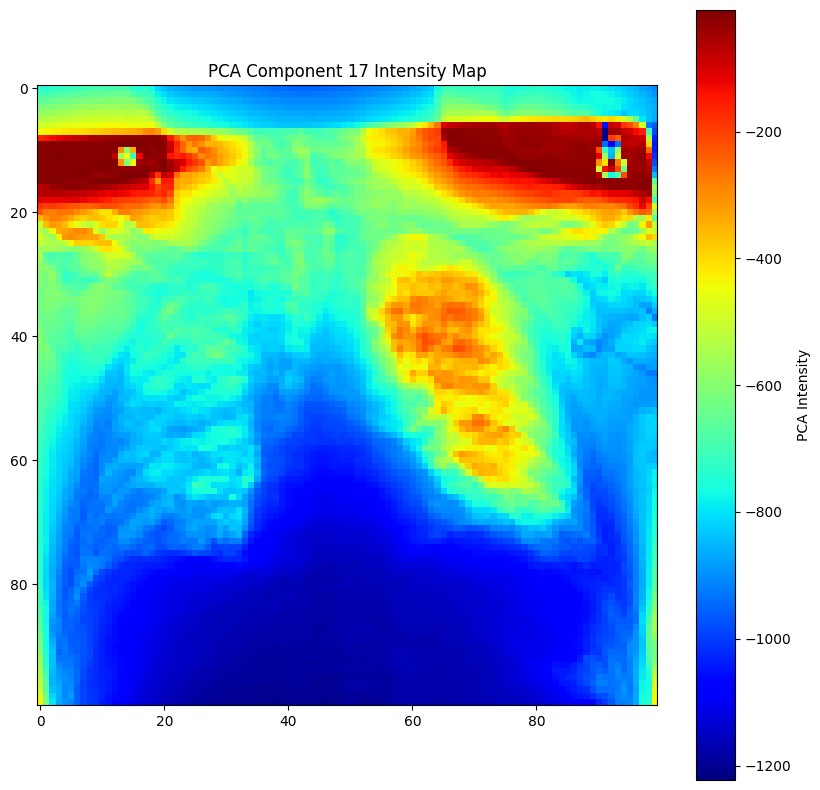

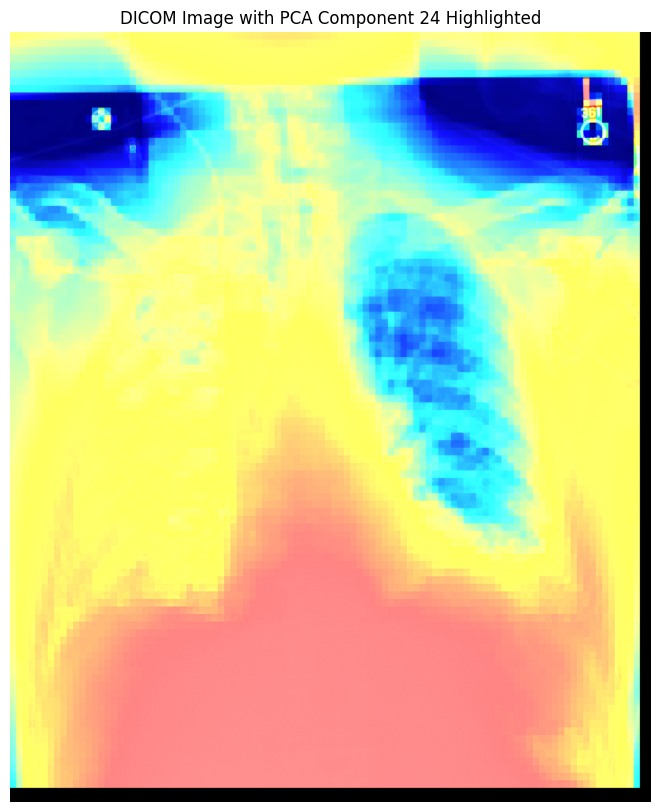

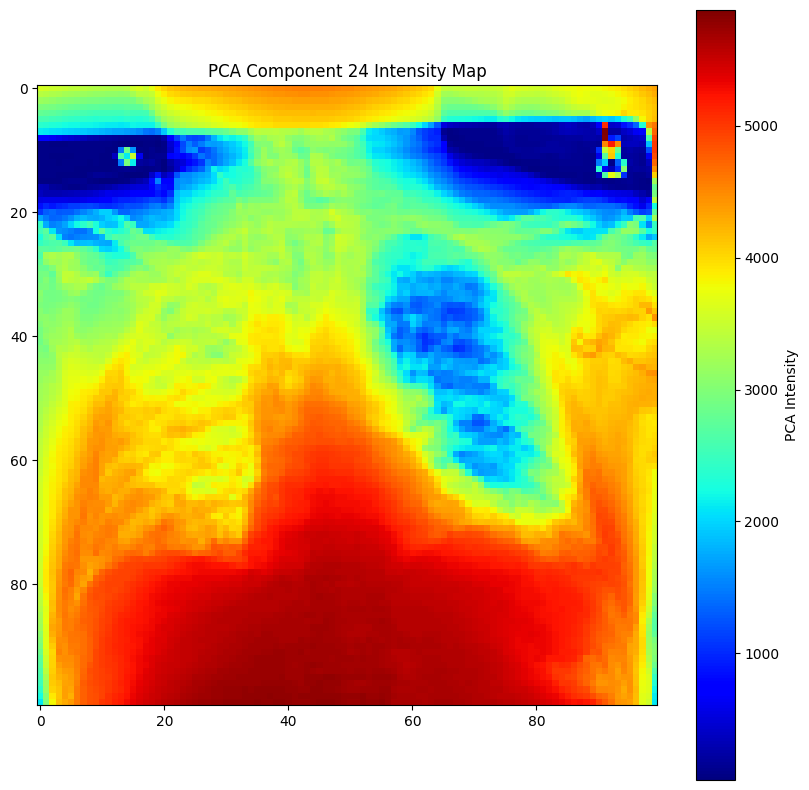

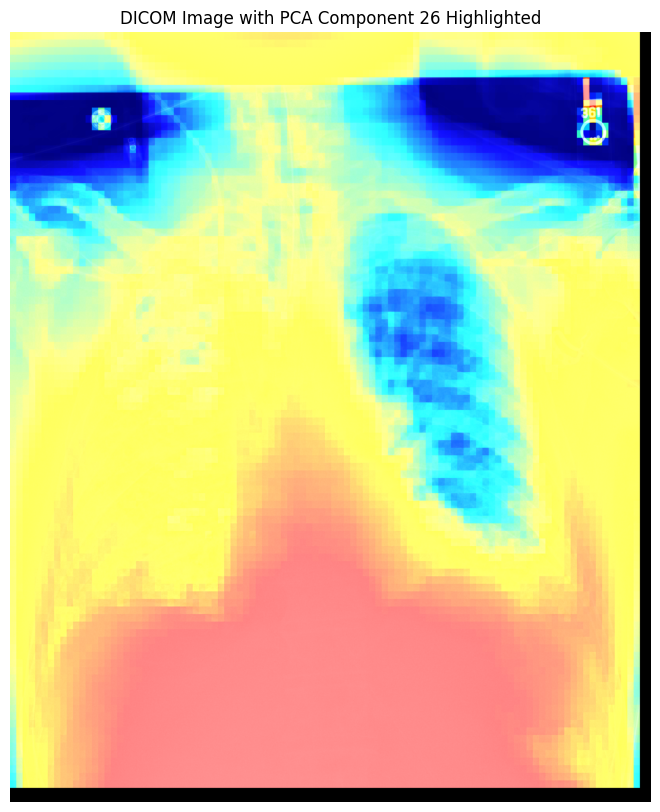

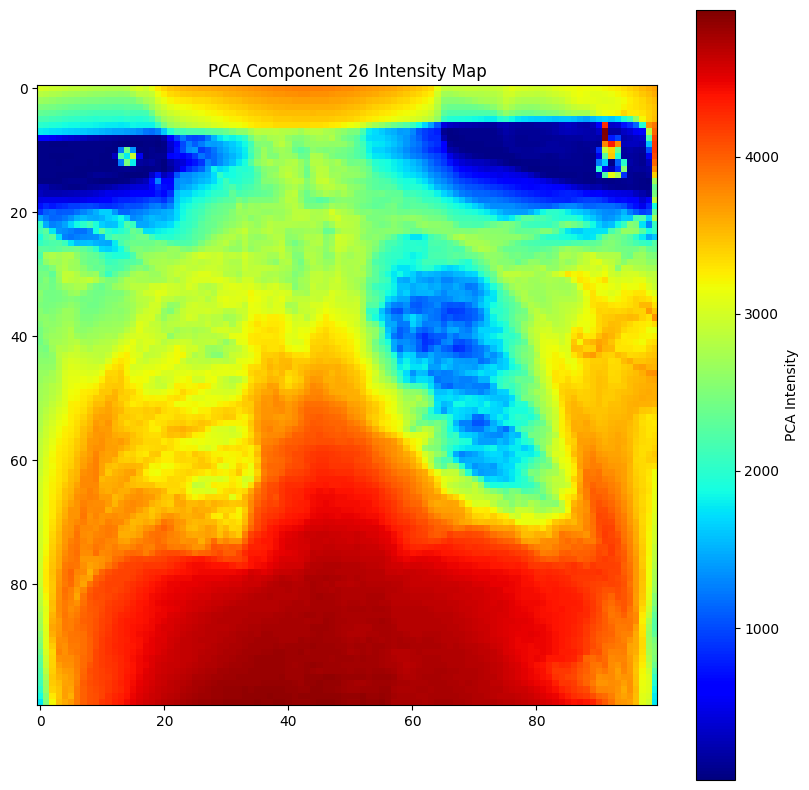

In [ ]:
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example3.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Function to parse TFRecord file
def _parse_function(proto):
    # Define your features
    keys_to_features = {
        'embedding': tf.io.FixedLenFeature([1376], tf.float32),
        'image/format': tf.io.FixedLenFeature([], tf.string),
        'image/id': tf.io.FixedLenFeature([], tf.string),
    }

    # Load one example
    parsed_features = tf.io.parse_single_example(proto, keys_to_features)

    return parsed_features['embedding']

# Path to the TFRecord file
tfrecord_path = '/tmp/example3.tfrecord'

# Download the TFRecord file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.tfrecord')
blob.download_to_filename(tfrecord_path)
# Download the DICOM file from the GCP bucket
blob = bucket.blob('embedded_datas/example3.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()

# Create a dataset from the TFRecord file
dataset = tf.data.TFRecordDataset([tfrecord_path])
dataset = dataset.map(_parse_function)

# Extract embeddings (assuming there's only one record in the file for simplicity)
for record in dataset.take(1):
    pca_features = record.numpy()

# Directly use significant components from regression analysis
significant_components = [5, 6, 17, 24, 26]  # Ensure these are within the range of pca_features

# Define ROIs (divide the image into a 40x40 grid)
height, width = image_array.shape
num_rois = 100
roi_height, roi_width = height // num_rois, width // num_rois

rois = [
    (slice(i * roi_height, (i + 1) * roi_height), slice(j * roi_width, (j + 1) * roi_width))
    for i in range(num_rois) for j in range(num_rois)
]

# Threshold for visualization
threshold = 1e4  # Example threshold value, adjust based on your data

for component in significant_components:
    if component - 1 >= len(pca_features):
        print(f"Component {component} is out of bounds for PCA features with length {len(pca_features)}")
        continue

    # Create an empty mask for the full image
    intensity_map = np.zeros((num_rois, num_rois))

    # Calculate PCA intensities for each ROI and store them in the intensity map
    for i, roi in enumerate(rois):
        pca_feature = pca_features[component - 1]

        # Extract the region from the DICOM image
        roi_image = image_array[roi]

        # Calculate the mean intensity of the PCA feature within this ROI
        pca_intensity = np.mean(roi_image) * pca_feature

        intensity_map[i // num_rois, i % num_rois] = pca_intensity

    # Normalize the intensity map for color mapping
    intensity_map_normalized = (intensity_map - np.min(intensity_map)) / (np.max(intensity_map) - np.min(intensity_map))

    # Create the overlay image with a color map and transparency
    overlay_image = np.zeros((*image_array.shape, 3), dtype=np.float32)
    alpha = 0.96  # Transparency level

    for i, roi in enumerate(rois):
        intensity = intensity_map_normalized[i // num_rois, i % num_rois]
        color = plt.cm.jet(intensity)[:3]  # Use a colormap (e.g., 'jet') to get the color
        for j in range(3):  # Apply color to the RGB channels
            overlay_image[roi[0], roi[1], j] = (1 - alpha) * (image_array[roi] / 255) + alpha * color[j]

    # Display the overlay image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay_image)
    plt.title(f'DICOM Image with PCA Component {component} Highlighted')
    plt.axis('off')
    plt.show()

    # Display the intensity map for reference
    plt.figure(figsize=(10, 10))
    plt.imshow(intensity_map, cmap='jet')
    plt.colorbar(label='PCA Intensity')
    plt.title(f'PCA Component {component} Intensity Map')
    plt.show()

    # Print the intensity values for each ROI
    #for i, roi in enumerate(rois):
    #    print(f"ROI {roi}: Intensity: {intensity_map[i // num_rois, i % num_rois]}")


# Linear regression with PEEP

Cross-Validation MSE scores: [17.38685612 16.78203072 15.52267231 14.03622961 13.07815876]
Mean CV MSE: 15.361189503602384


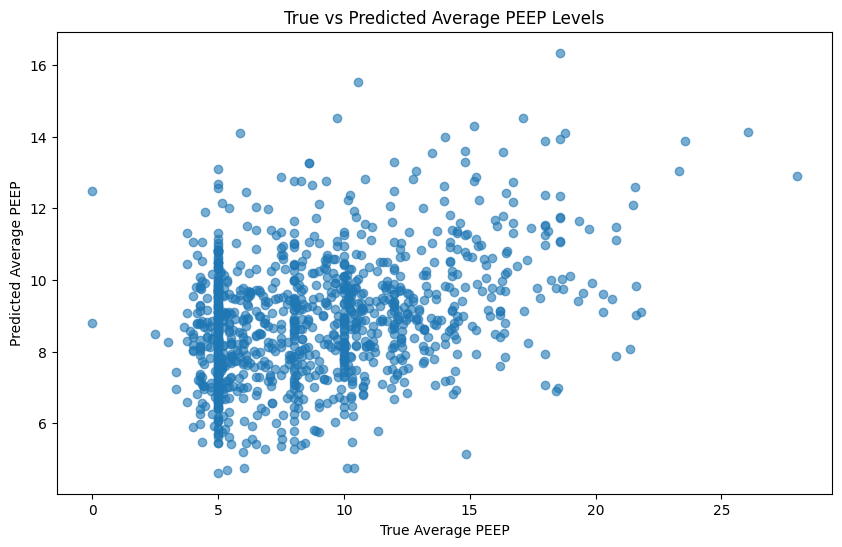

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
import matplotlib.pyplot as plt

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
y = df['avg_peep']

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores = -cv_scores
print("Cross-Validation MSE scores:", cv_mse_scores)
print("Mean CV MSE:", np.mean(cv_mse_scores))

# Predict on the test set
y_pred = model.predict(X_test)

# Add predictions to the DataFrame
df['predicted_avg_peep'] = model.predict(X)

# Plot true vs predicted average PEEP levels
plt.figure(figsize=(10, 6))
plt.scatter(y, df['predicted_avg_peep'], alpha=0.6)
plt.xlabel('True Average PEEP')
plt.ylabel('Predicted Average PEEP')
plt.title('True vs Predicted Average PEEP Levels')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Assuming df is already loaded and contains embeddings and avg_peep

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
y = df['avg_peep']

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
print (X_train)
# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_mse_scores = -cv_scores
print("Cross-Validation MSE scores:", cv_mse_scores)
print("Mean CV MSE:", np.mean(cv_mse_scores))

# Predict on the test set
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluation metrics
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

print(f"Train MSE: {train_mse}, Test MSE: {test_mse}")
print(f"Train RMSE: {train_rmse}, Test RMSE: {test_rmse}")
print(f"Train R2: {train_r2}, Test R2: {test_r2}")
print(f"Train MAE: {train_mae}, Test MAE: {test_mae}")

# Add predictions to the DataFrame
df['predicted_avg_peep'] = model.predict(X)

# Plot true vs predicted average PEEP levels
plt.figure(figsize=(10, 6))
plt.scatter(y, df['predicted_avg_peep'], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('True Average PEEP')
plt.ylabel('Predicted Average PEEP')
plt.title('True vs Predicted Average PEEP Levels (Entire Dataset)')
plt.show()

# Plot residuals
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('True Average PEEP')
plt.ylabel('Residuals')
plt.title('Residuals of the Model')
plt.show()


# Logistic Regression (high/low) with PEEP

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

peep = df['avg_peep']
y = [1 if component >= 10 else 0 for component in peep]

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the test set
y_pred = model.predict(X_test)

# Add predictions to the DataFrame
df['predicted_avg_peep'] = model.predict(X)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Low', 'Predicted High'], yticklabels=['True Low', 'True High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print the classification report
print(classification_report(y_test, y_pred, target_names=['Low PEEP', 'High PEEP']))

# Identify correct and incorrect predictions
test_indices = X_test.index
correct_predictions = test_indices[y_test == y_pred]
incorrect_predictions = test_indices[y_test != y_pred]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df.loc[incorrect_predictions].head())


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Assuming embeddings and avg_peep are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and avg_peep
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

# Binarize the avg_peep values
peep = df['avg_peep']
y = [1 if component >= 10 else 0 for component in peep]

# Apply PCA
pca = PCA(n_components=50)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(30)]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate and print accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Test Set Accuracy:", accuracy)
print("Test Set Precision:", precision)
print("Test Set Recall:", recall)
print("Test Set F1 Score:", f1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Plot true vs predicted average PEEP levels
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('True Binary PEEP')
plt.ylabel('Predicted Binary PEEP')
plt.title('True vs Predicted Binary PEEP Levels')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming embeddings and icu_mortality are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and icu_mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

mortality = df['icu_mort']

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for classification analysis
X = df[[f'pca_{i+1}' for i in range(30)]]
y = mortality

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the classification model
model = LogisticRegression()

# Perform cross-validation and hyperparameter tuning
param_grid = {'C': [0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Train the best model on the full training set
best_model.fit(X_train, y_train)

# Cross-validation scores
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the test set
y_pred = best_model.predict(X_test)

# Add predictions to the DataFrame
df['predicted_icu_mortality'] = best_model.predict(X)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Survived', 'Predicted Mortality'], yticklabels=['True Survived', 'True Mortality'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print the classification report
print(classification_report(y_test, y_pred, target_names=['Survived', 'Mortality']))

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test Set Accuracy:", accuracy)

# Identify correct and incorrect predictions
test_indices = X_test.index
correct_predictions = test_indices[y_test == y_pred]
incorrect_predictions = test_indices[y_test != y_pred]

# Display some rows from the raw dataset where predictions were correct
print("\nCorrect Predictions:")
print(df.loc[correct_predictions].head())

# Display some rows from the raw dataset where predictions were incorrect
print("\nIncorrect Predictions:")
print(df.loc[incorrect_predictions].head())


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Assuming embeddings and icu_mort are loaded into df
# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Extract embedding vectors and icu_mort
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

icu_mort = df['icu_mort']

# Apply PCA
pca = PCA(n_components=30)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the DataFrame
df_pca = pd.DataFrame(embeddings_pca, columns=[f'pca_{i+1}' for i in range(embeddings_pca.shape[1])])
df_pca['icu_mort'] = icu_mort.values

# Prepare the data for classification analysis
X = df_pca.drop('icu_mort', axis=1)
y = df_pca['icu_mort']

# Define the oversampling and undersampling strategy
over = SMOTE(sampling_strategy=0.5)
under = RandomUnderSampler(sampling_strategy=0.8)
steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

# Transform the dataset
X_resampled, y_resampled = pipeline.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Define the classification model
model = LogisticRegression()

# Perform cross-validation and hyperparameter tuning
param_grid = {'C': [0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Train the best model on the full training set
best_model.fit(X_train, y_train)

# Cross-validation scores
cv_scores = cross_val_score(best_model, X_resampled, y_resampled, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Predict on the test set
y_pred = best_model.predict(X_test)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Survived', 'Predicted Mortality'], yticklabels=['True Survived', 'True Mortality'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Print the classification report
print(classification_report(y_test, y_pred, target_names=['Survived', 'Mortality']))

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("Test Set Accuracy:", accuracy)

# Identify correct and incorrect predictions
test_indices = X_test.index
correct_predictions = test_indices[y_test == y_pred]
incorrect_predictions = test_indices[y_test != y_pred]


# Random Forest regressor with PEEP

Regression summary for PCA component 5
                            OLS Regression Results                            
Dep. Variable:               avg_peep   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     4.093
Date:                Tue, 30 Jul 2024   Prob (F-statistic):             0.0438
Time:                        15:53:17   Log-Likelihood:                -959.79
No. Observations:                 356   AIC:                             1924.
Df Residuals:                     354   BIC:                             1931.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:425: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
210 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Train MSE: 6.037190638494665, Test MSE: 12.123228797876264
Train R2: 0.5455832064255657, Test R2: -0.024424256441937464


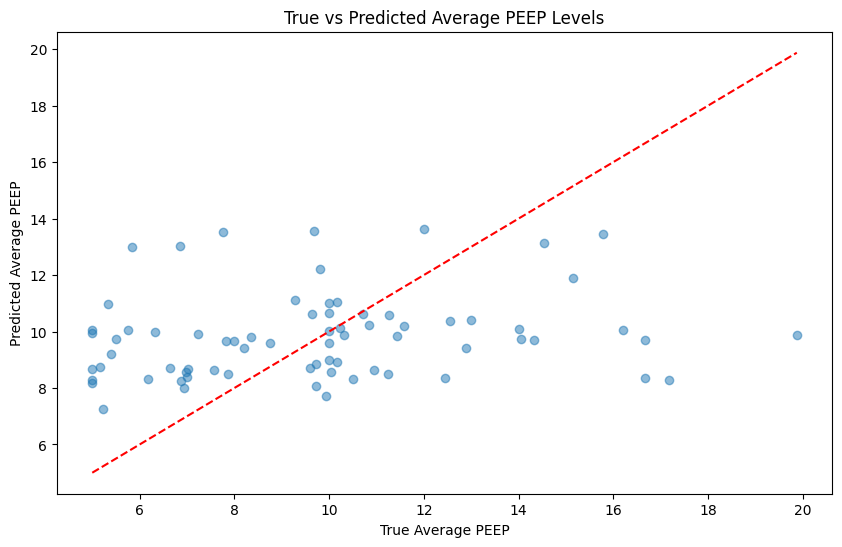

Cross-Validation MSE scores: [14.82835545 12.63563465 11.45613802 11.39284335  9.76890209]
Mean CV MSE: 12.016374712152203


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming df is already loaded and embeddings are extracted
# Choose the number of components based on the elbow method graph
chosen_components = 30

# Apply PCA with chosen number of components
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(chosen_components)]]
y = df['avg_peep']

# Univariate PCA logistic regression (changing from multivariate to univariate)
# Here we use each PCA component individually to fit the regression model
significant_components = []
for i in range(chosen_components):
    Xi = sm.add_constant(X[[f'pca_{i+1}']])
    model = sm.OLS(y, Xi)
    result = model.fit()
    p_value = result.pvalues[f'pca_{i+1}']
    if p_value < 0.05:
        significant_components.append(i+1)
        print(f'Regression summary for PCA component {i+1}')
        print(result.summary())

# Using the significant PCA components for Random Forest Regressor
X_significant = df[[f'pca_{i+1}' for i in significant_components]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_significant, y, test_size=0.2, random_state=42)

# Define the model
rf = RandomForestRegressor()

# Define hyperparameters for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search for hyperparameter tuning
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best parameters and model
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

# Predictions
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

# Evaluation
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f'Train MSE: {train_mse}, Test MSE: {test_mse}')
print(f'Train R2: {train_r2}, Test R2: {test_r2}')

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('True Average PEEP')
plt.ylabel('Predicted Average PEEP')
plt.title('True vs Predicted Average PEEP Levels')
plt.show()

# Cross-Validation
from sklearn.model_selection import cross_val_score
cross_val_scores = cross_val_score(best_rf, X_significant, y, cv=5, scoring='neg_mean_squared_error')
mean_cv_mse = -cross_val_scores.mean()

print(f'Cross-Validation MSE scores: {-cross_val_scores}')
print(f'Mean CV MSE: {mean_cv_mse}')

   PCA Component  Coefficient       P-Value     R-Squared  \
0          pca_1     0.017338  2.906745e-01  1.001288e-03   
1          pca_2    -0.006372  7.664949e-01  7.912374e-05   
2          pca_3     0.037050  1.475582e-01  1.880073e-03   
3          pca_4    -0.061210  3.501773e-02  3.979776e-03   
4          pca_5     0.201228  5.665308e-11  3.778943e-02   
5          pca_6    -0.005448  8.655558e-01  2.571935e-05   
6          pca_7     0.063604  7.164817e-02  2.907252e-03   
7          pca_8    -0.028745  4.350881e-01  5.464659e-04   
8          pca_9    -0.174641  7.999835e-06  1.773047e-02   
9         pca_10    -0.220071  3.089096e-07  2.322814e-02   
10        pca_11     0.063065  1.737673e-01  1.658684e-03   
11        pca_12     0.163802  7.464039e-04  1.015001e-02   
12        pca_13    -0.033409  5.123638e-01  3.850641e-04   
13        pca_14     0.069332  2.039110e-01  1.447259e-03   
14        pca_15    -0.205833  3.089497e-04  1.161026e-02   
15        pca_16     0.0

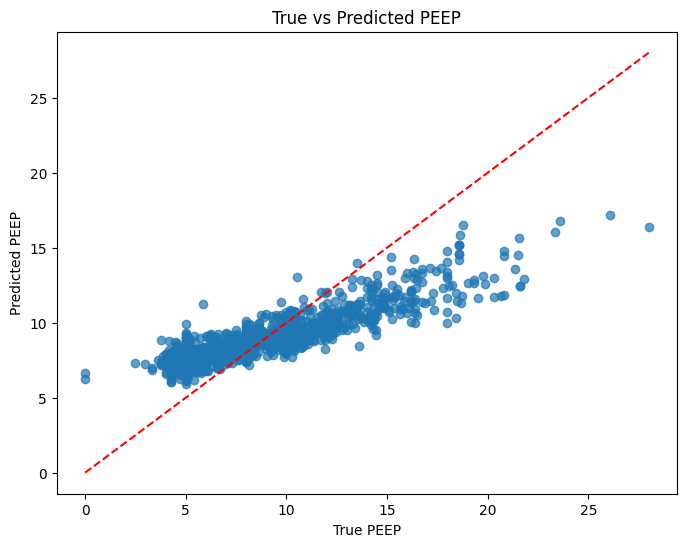

In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

# Choose the number of components based on the elbow method graph
chosen_components = 50

# Apply PCA with chosen number of components
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(chosen_components)]]
y = df['avg_peep']

# Univariate PCA regression analysis
results_list = []

for i in range(chosen_components):
    Xi = sm.add_constant(X[[f'pca_{i+1}']])
    model = sm.OLS(y, Xi)
    result = model.fit()
    p_value = result.pvalues[f'pca_{i+1}']
    confidence_interval = result.conf_int().loc[f'pca_{i+1}'].values
    r_squared = r2_score(y, result.predict(Xi))
    coefficient = result.params[f'pca_{i+1}']

    results_list.append({
        'PCA Component': f'pca_{i+1}',
        'Coefficient': coefficient,
        'P-Value': p_value,
        'R-Squared': r_squared,
        'Confidence Interval': confidence_interval
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Display the table
print(results_df)

# Filter significant components based on p-value < 0.1
significant_components = results_df[results_df['P-Value'] < 0.1]['PCA Component']
print("Significant Components (P-Value < 0.1):")
print(significant_components)

# Prepare data with significant components for multivariate regression
X_significant = df[significant_components]

# Define the model
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [None, 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform the grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_significant, y)

# Output the best parameters
print("Best parameters found: ", grid_search.best_params_)

# Train the final model with the best parameters
best_rf = grid_search.best_estimator_

# Predict on the same dataset
y_pred = best_rf.predict(X_significant)

# Calculate R-squared value
r2 = r2_score(y, y_pred)
print(f"R-squared value: {r2}")

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate Mean Absolute Error
mae = mean_absolute_error(y, y_pred)
print(f"Mean Absolute Error: {mae}")

# Calculate variance of the residuals (prediction errors)
variance = np.var(y_pred - y)
print(f"Variance: {variance}")

# Optionally, visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.xlabel('True PEEP')
plt.ylabel('Predicted PEEP')
plt.title('True vs Predicted PEEP')
plt.show()

   PCA Component  Coefficient       P-Value  R-Squared  \
0          pca_1     0.017338  2.906745e-01   0.001001   
1          pca_2    -0.006372  7.664949e-01   0.000079   
2          pca_3     0.037050  1.475582e-01   0.001880   
3          pca_4    -0.061210  3.501773e-02   0.003980   
4          pca_5     0.201228  5.665308e-11   0.037789   
..           ...          ...           ...        ...   
95        pca_96     0.194184  3.225873e-01   0.000878   
96        pca_97    -0.035614  8.569383e-01   0.000029   
97        pca_98     0.176621  3.757385e-01   0.000704   
98        pca_99    -0.229347  2.542196e-01   0.001166   
99       pca_100    -0.034450  8.651001e-01   0.000026   

                              Confidence Interval  
0    [-0.014841882865923549, 0.04951790570863245]  
1     [-0.04846571660419464, 0.03572095869018931]  
2    [-0.013112045756338356, 0.08721249636171469]  
3   [-0.11811056549683921, -0.004310394320038442]  
4       [0.1415630162557301, 0.260893431095

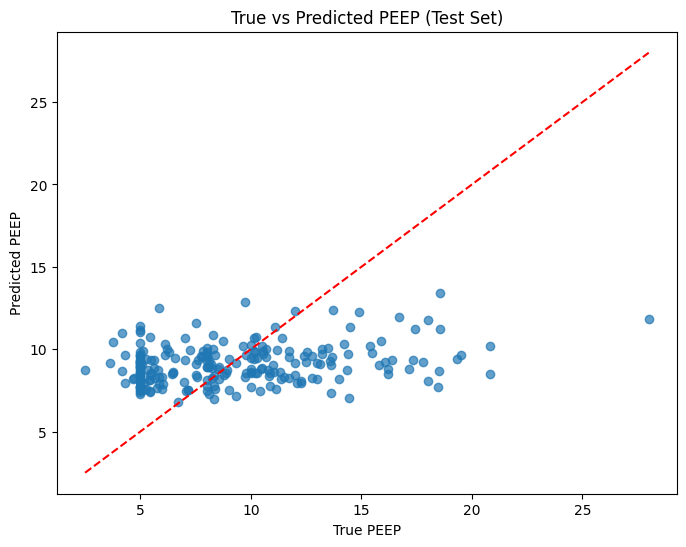

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split

# Assuming df is already loaded with necessary data

embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]

# Choose the number of components based on the elbow method graph
chosen_components = 100

# Apply PCA with chosen number of components
pca = PCA(n_components=chosen_components)
embeddings_pca = pca.fit_transform(embeddings)

# Add PCA components to the dataframe
for i in range(embeddings_pca.shape[1]):
    df[f'pca_{i+1}'] = embeddings_pca[:, i]

# Prepare the data for regression analysis
X = df[[f'pca_{i+1}' for i in range(chosen_components)]]
y = df['avg_peep']

# Univariate PCA regression analysis
results_list = []

for i in range(chosen_components):
    Xi = sm.add_constant(X[[f'pca_{i+1}']])
    model = sm.OLS(y, Xi)
    result = model.fit()
    p_value = result.pvalues[f'pca_{i+1}']
    confidence_interval = result.conf_int().loc[f'pca_{i+1}'].values
    r_squared = r2_score(y, result.predict(Xi))
    coefficient = result.params[f'pca_{i+1}']

    results_list.append({
        'PCA Component': f'pca_{i+1}',
        'Coefficient': coefficient,
        'P-Value': p_value,
        'R-Squared': r_squared,
        'Confidence Interval': confidence_interval
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Display the table
print(results_df)

# Filter significant components based on p-value < 0.1
significant_components = results_df[results_df['P-Value'] < 0.1]['PCA Component']
print("Significant Components (P-Value < 0.1):")
print(significant_components)

# Prepare data with significant components for multivariate regression
X_significant = df[significant_components]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_significant, y, test_size=0.2, random_state=42)

# Define the model
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [None, 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform the grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Output the best parameters
print("Best parameters found: ", grid_search.best_params_)

# Train the final model with the best parameters
best_rf = grid_search.best_estimator_

# Predict on the training set
y_train_pred = best_rf.predict(X_train)

# Predict on the test set
y_test_pred = best_rf.predict(X_test)

# Calculate and print metrics for the training set
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
print(f"Training R-squared value: {train_r2}")
print(f"Training Mean Squared Error: {train_mse}")
print(f"Training Mean Absolute Error: {train_mae}")

# Calculate and print metrics for the test set
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f"Test R-squared value: {test_r2}")
print(f"Test Mean Squared Error: {test_mse}")
print(f"Test Mean Absolute Error: {test_mae}")

# Optionally, visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('True PEEP')
plt.ylabel('Predicted PEEP')
plt.title('True vs Predicted PEEP (Test Set)')
plt.show()
